## Algoritmul PageRank (Google)

Pentru un motor de căutare se pune problema ierarhizării rezultatelor. Pentru aceasta trebuie să acordăm un scor fiecărei pagini, scor care să măsoare „influența” acesteia. 

Reprezentăm rețeau ca un graf orientat cu noduri reprezentate de pagini, iar între două noduri există o muchie dacă există o legătură între pagini. Un astfel de graf este
mai jos. 

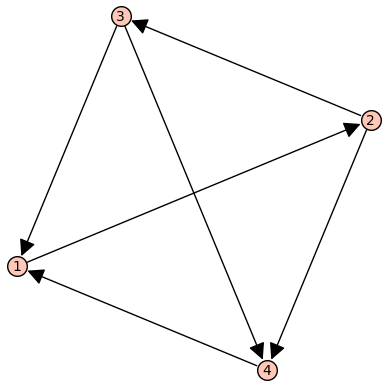

In [7]:
from sage.graphs.graph_plot import GraphPlot
options = {
     'vertex_size': 200,
     'vertex_labels': True,
     'layout': None,
     'edge_style': 'solid',
     'edge_color': 'black',
     'edge_colors': None,
     'edge_labels': False,
     'iterations': 50,
     'tree_orientation': 'down',
     'heights': None,
     'graph_border': False,
     'talk': False,
     'color_by_label': False,
     'partition': None,
     'dist': .075,
     'max_dist': 1.5,
     'loop_size': .075,
     'edge_labels_background': 'transparent'}
g = DiGraph({1: [2], 2: [3,4], 3: [4, 1],4: [1]})
GP = GraphPlot(g,options)
GP.show()

Unui astfel de graf îi asociem **matricea de conectivitate** $A=\left(a_{ij}\right)$ cu $i,j=\overline{1,n},$ unde $n$ este numărul de muchii. Coeficienții sînt dați de 
$$
a_{ji} = \left\{\begin{array}{cccc} \frac{1}{k_j} & \text{ dacă există o muchie de la } i \text{ la } j \\
0 & \text {în rest,} \end{array} \right.
$$
unde $k_j$ este numărul de muchii care pleacă din nodul $j$. Pentru exemplul nostru

$$
A=\left(\begin{array}{cccc} 0 & 0 & 1/2 & 1 \\ 1 & 0 & 0 & 0 \\ 0 & 1/2 & 0 & 0 \\ 0 & 1/2 & 1/2 & 0 \end{array}\right).
$$

Presupunem că nu există în graf nici o muche care unește un nod cu el însuși. Atunci matricea de conectivitate are următoarele proprietăți:
 - suma elementelor de pe coloane este $1;$
 - toate elementele de pe diagonală sînt $0;$
 - are valoare proprie $1.$

Presupunem că la început toate paginile au același scor $\frac{1}{4}.$ Aplicăm $A$ în mod repetat, ceea ce revine la a calcula repetat influența fiecărei pagini.

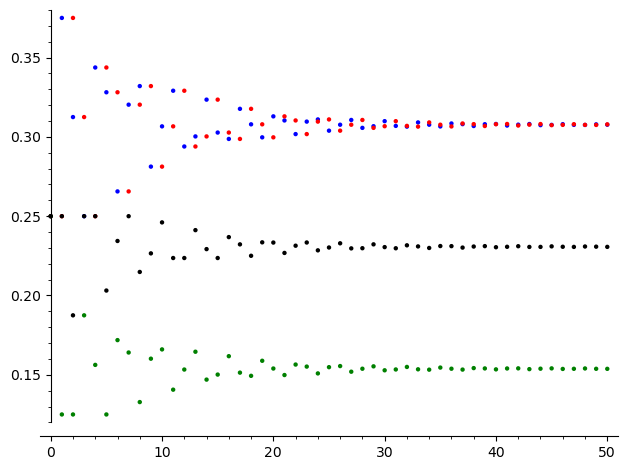

In [1]:
A=matrix(QQ,[[0,0,1/2,1],[1,0,0,0],[0,1/2,0,0],[0,1/2,1/2,0]])
v=vector([1/4,1/4,1/4,1/4])
v0=v
l0=[v[0]]
l1=[v[1]]
l2=[v[2]]
l3=[v[3]]
for n in range(50):
    w = A*v0
    l0.append(w[0])
    l1.append(w[1])
    l2.append(w[2])
    l3.append(w[3])
    v0=w
p0 = list_plot(l0)
p1 = list_plot(l1,color = 'red')
p2 = list_plot(l2,color = 'green')
p3 = list_plot(l3,color = 'black')
(p0+p1+p2+p3).show()

Se vede că fiecare componentă va tinde către o valoare finită. Dacă punem aceste valori într-un vector $v_0$ avem că $Av_0 = v_0,$ adică este un vector propriu corespunzător valorii proprii $1$. Vectorul scorurilor va fi acel vector propriu cu $v_0$ cu valori pozitive și avînd suma elementelor egală cu $1$. Concret luăm acel vector propriu $v=(v_1,\dots,v_n)$ cu toți termenii pozitivi, facem $s=v_1+\dots+v_n$, iar vectorul scorurilor va fi $1/sv_0$. La noi avem 
$v_0 = (1,1,1/2,3/4)$ , $ s=13/4$ și deci vectorul scorurilor este $p=(4/13,4/13,2/13,3/13)$.

In [2]:
A.eigenvectors_right()

[(1, [(1, 1, 1/2, 3/4)], 1),
 (-0.3194484597356763?,
  [(1, -3.130395434767279?, 4.899687789005910?, -2.769292354238632?)],
  1),
 (-0.3402757701321619? - 0.8165851204576188?*I,
  [(1, -0.4348022826163606? + 1.043427435893032?*I, -0.4498438945029551? - 0.4536846308708267?*I, -0.11535382288068429? - 0.5897428050222055?*I)],
  1),
 (-0.3402757701321619? + 0.8165851204576188?*I,
  [(1, -0.4348022826163606? - 1.043427435893032?*I, -0.4498438945029551? + 0.4536846308708267?*I, -0.11535382288068429? + 0.5897428050222055?*I)],
  1)]

In [3]:
t=1+1+1/2+3/4

In [4]:
numerical_approx(1/t*vector(QQ,[1/1,1/1,1/2,3/4]))

(0.307692307692308, 0.307692307692308, 0.153846153846154, 0.230769230769231)

# Spații afine

**Definiție** Un spațiu afin este o pereche $(V,L),$ un $V$ este o mulțime de puncte și $L$ este un spațiu vectorial, numit spațiul director, astfel că fiecărei perechi de puncte $A,B \in V$ i se asociază un vector $\overrightarrow{AB} \in L$ astfel încît:
  1. $\overrightarrow{AB}+\overrightarrow{BC} = \overrightarrow{AC}$ pentru orice $A,B,C \in V;$
  2. pentru orice puncte $A,B,C \in V$ există un unic $D \in V$ a.î. $\overrightarrow{AB}=\overrightarrow{CD}.$
  3. pentru orice două puncte $A,B \in V$ și orice scalar $a$ există și este unic un punct $C$ a.î. $a\overrightarrow{AB}=\overrightarrow{AC}.$

Deoarece $L'=\left\{\overrightarrow{AB}| A,B \in V \right\}$ este un subspațiu al lui $L$ putem să reducem spațiul $L$ la $L'$, pe care îl vom nota tot cu $L$. 

Un exemplu de spațiu afin este perechea $(L,L)$ unde pentru doi vectori $a,b \in L$ definim $\overrightarrow{ab}=b-a.$ 

Din condiția 2. rezultă că oricum am fixa un punct $O \in V$ atunci orice vector din $L$ este de forma $\overrightarrow{OA}$ cu un $A \in V.$ În acest fel obținem o bijecție între $V$ și $L$. Putem să ne gîndim că un spațiu afin este un spațiu vectorial în care nu am fixat originea. 

**Definiție** Fie $(V,L)$ un spațiu afin. Dimensiunea sa este $\dim L.$ Un spațiu afin de dimensiune $1$ se numește dreaptă, iar unul de dimensiune $2$ se numește plan.

Dacă am fixat o origine $O \in V$ și o bază $(e_1,\dots,e_n)$ a lui $L$ atunci orice punct $A$ poate fi descris de coordonatele lui $\overrightarrow{OA}$ în raport cu această bază. Formal avem următoarea definiție

**Definiție** Se numește reper sau sistem de referință a lui $V$ o pereche $\left(O;e_1,\dots,e_n\right),$ unde $O \in V$ și $\left\{e_1,\dots,e_n\right\}$ e o bază în $L$.

La rîndul lor fiecare vector $e_i$ este de forma $\overrightarrow{OA_i}$. Deci a alege un reper este echivalent cu a alege $n+1$ puncte $O,A_1,\dots,A_n$ astfel încît $\overrightarrow{OA_1},\dots,\overrightarrow{OA_n}$ sînt liniar-independenți. Spunem că aceste puncte sînt **afin-independente**.

**Definiție** Un subspațiu afin este o submulțime $V' \subset V$ astfel încît $L'=\left\{\overrightarrow{AB}| A,B \in V' \right\}$ este un subspațiu vectorial al lui $L.$ Dacă $\dim V' = \dim V -1$ atunci $V'$ se numește **hiperplan.**

Un exemplu de subspațiu afin este mulțimea soluțiilor unui sistem liniar neomogen. Reciproc pentru orice subspațiu afin există un sistem de ecuații liniare pentru care acesta este mulțimea soluțiilor.

**Definiție** Două subspații afine $V'$ și $V''$ se numesc paralele dacă $L' \subset L''$ sau $L'' \subset L'.$

Considerăm două puncte $A,B \in V$. Luînd toate punctele $C$ determinate de condiția 3. pentru toți scalarii $a$ obținem un subspațiu afin cu directorul $\langle \overrightarrow{AB}\rangle,$ adică o dreaptă. Dacă lucrăm peste un corp de caracteristică diferită de $2$ atunci avem următoarea caracterizare a subspațiilor afine:

**Teoremă** O submulțime $V' \subset V$ este subspațiu afin dacă o dată cu două puncte $A,B$ conține întreaga dreaptă $AB.$

Revenind la independența afină avem că niște puncte $A_0,\dots,A_n$ sînt afin-independente dacă $\overrightarrow{A_0A_1},\dots,\overrightarrow{A_0A_n}$ sînt liniar-independenți.

## Aplicații afine

**Definiție** O aplicație afină între două spații afine $(V,L)$ și $(V',L')$ este o pereche de aplicații $f:V \to V'$ și $\mathcal{F}:L \to L'$ a.î. 
  1. $\mathcal{F}$ este liniară;
  2. $\overrightarrow{f(A)f(B)} = \mathcal{F}(\overrightarrow{AB}).$

$\mathcal{F}$ se numește partea liniară a lui $f$ și se notează $\Lambda(f)$.

Aplicațiile afine au următoarele proprietăți:

  1. Compunerea a două aplicații afine $f,g$ este afină și $\Lambda(fg)=\Lambda(f)\Lambda(g);$
  2. O aplicație afină este bijectivă dacă și numai dacă partea sa liniară este bijectivă;
  3. Dacă $f$ este aplicația identică, atunci partea sa liniară este identitatea.

Reciproca proprietății 3. de mai sus nu e adevărată. Considerăm următoarea construcție: fie $v \in L$ un vector fixat. Definim $\mathcal{T}_v(A)=B$, unde $B$ satisface $\overrightarrow{AB}=v$. Se vede că partea liniară a oricărei translații este identitatea.

Mai general dacă două aplicații afine au aceleași părți liniare, atunci diferă printr-o translație. 

## Spații afine euclidiene

**Definiție** Un spațiu afin $(V,L)$ se numește afin euclidian dacă $L$ este spațiu euclidian.

Structura de spațiu euclidian de pe $L$ ne permite să definim o distanță pa $V$ prin $d(A,B)=|\overrightarrow{AB}|.$ 

**Definiție** Două subspații $(V_1,L_1)$ și $(V_2,L_2)$ se numesc perpendiculare dacă $L_1 \subset L_2^\perp$ sau $L_2^\perp \subset L_1.$ 

O aplicație afină $f$ se numește **deplasare** (izometrie) dacă păstrează distanța între puncte: $d(f(A),f(B))=d(A,B)$. Avem următoarea caracterizare a deplasărilor:

**Teoremă** Orice deplasare $f:V \to V$ se poate scrie ca $$f=\mathcal{T}_vg,$$ unde $g$ are un punct fix cu partea liniară o aplicație ortogonală și $\Lambda(g)v=v$.